# Parsing the results of the cross-sens experiments

## 1. fMoW

kNN across 3 models

In [4]:
import pandas as pd
import numpy as np

# Create empty dataframes for each model and metric
models = ['dofa-null', 'panopticon_v3-null', 'senpamae-null']
metrics = ['F1Score', 'acc_top-1_macro', 'acc_top-1_micro']
datasets = ['fmow_4b', 'fmow_8b', 'fmow_s2']

# Initialize dictionaries to store dataframes for each model and metric
model_dfs = {}

for model in models:
    model_dfs[model] = {}
    for metric in metrics:
        model_dfs[model][metric] = pd.DataFrame(index=datasets, columns=datasets)

# Parse the data from the CSV
data = []

results_path = "/data/panopticon/logs/fm_logs/cross_sens/fmow/knn/panopticon_v3-null/fmow_8b-fmow_8b/k=[20]_T=[0.07]_norm=['all', 'batchwise', 'none']/results.csv"

with open(results_path, 'r') as f:
    # Skip header
    next(f)
    for line in f:
        parts = line.strip().split(',')
        if len(parts) >= 5:
            idx = int(parts[0])
            metric = parts[1].strip('"')
            val = float(parts[2])
            relpath = parts[4].strip('"')
            
            # Extract model and datasets from relpath
            path_parts = relpath.split('/')
            if len(path_parts) >= 3:
                model = path_parts[1]
                ds_parts = path_parts[2].split('-')
                if len(ds_parts) >= 2:
                    train_ds = ds_parts[0]
                    test_ds = ds_parts[1]
                    
                    # Add to the appropriate dataframe
                    if model in model_dfs and metric in model_dfs[model]:
                        model_dfs[model][metric].loc[train_ds, test_ds] = val

# Print the dataframes
for model in models:
    print(f"\n{model} Results:")
    for metric in metrics:
        print(f"\n{metric}:")
        print(model_dfs[model][metric])


dofa-null Results:

F1Score:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

acc_top-1_macro:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

acc_top-1_micro:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

panopticon_v3-null Results:

F1Score:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

acc_top-1_macro:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

acc_top-1_micro:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN     NaN
fmow_8b     NaN     NaN     NaN
fmow_s2     NaN     NaN     NaN

senpamae-null Results:

F1Score:
        fmow_4b fmow_8b fmow_s2
fmow_4b     NaN     NaN  

In [9]:
import pandas as pd
import numpy as np

# Create empty dataframes for each model and metric
models = ['dofa-null', 'panopticon_v3-null', 'senpamae-null']
# metrics = ['F1Score' 'acc_top-1_macro' 'acc_top-1_micro']
metrics = ['acc_top-1_micro'] #
datasets = ['fmow_4b', 'fmow_8b', 'fmow_s2']

# Initialize dictionaries to store dataframes for each model and metric
model_dfs = {}

for model in models:
    model_dfs[model] = {}
    for metric in metrics:
        model_dfs[model][metric] = pd.DataFrame(index=datasets, columns=datasets)

# Debug: Print the structure we're looking for
print("Looking for these models:", models)
print("Looking for these metrics:", metrics)
print("Looking for these datasets:", datasets)

# Read the CSV file
df = pd.read_csv(results_path)

# Debug: Print the first few rows to understand the structure
print("\nFirst few rows of the CSV:")
print(df.head())

# Debug: Check unique values in relevant columns
print("\nUnique values in 'metric':", df['metric'].unique())
print("\nUnique values in 'relpath':", df['relpath'].unique()[:5])  # Show just first 5 for brevity

# Process each row in the dataframe
matched_count = 0
total_rows = len(df)

for _, row in df.iterrows():
    metric = row['metric']
    val = float(row['val'])
    relpath = row['relpath']
    
    # Extract model and datasets from relpath
    path_parts = relpath.split('/')
    
    # Debug: Print the path parts to understand the structure
    if len(path_parts) < 2:
        print(f"Warning: Not enough path parts in {relpath}")
        continue
        
    model = path_parts[1]  # The model should be the second part
    
    if model not in models:
        print(f"Warning: Model {model} not in expected models list")
        continue
        
    ds_parts = path_parts[2].split('-')
    
    if len(ds_parts) < 2:
        print(f"Warning: Not enough dataset parts in {path_parts[2]}")
        continue
        
    train_ds = ds_parts[0]
    test_ds = ds_parts[1]
    
    if train_ds not in datasets:
        print(f"Warning: Train dataset {train_ds} not in expected datasets list")
        continue
        
    if test_ds not in datasets:
        print(f"Warning: Test dataset {test_ds} not in expected datasets list")
        continue

    # print(model_dfs)
    
    # Add to the appropriate dataframe
    if metric in model_dfs[model]:
        model_dfs[model][metric].loc[train_ds, test_ds] = val
        matched_count += 1

# Debug: Print matching statistics
print(f"\nMatched {matched_count} out of {total_rows} rows")

# Print the dataframes
for model in models:
    print(f"\n{model} Results:")
    for metric in metrics:
        print(f"\n{metric}:")
        print(model_dfs[model][metric])

Looking for these models: ['dofa-null', 'panopticon_v3-null', 'senpamae-null']
Looking for these metrics: ['acc_top-1_micro']
Looking for these datasets: ['fmow_4b', 'fmow_8b', 'fmow_s2']

First few rows of the CSV:
   Unnamed: 0           metric   val                      best_classifier  \
0           0          F1Score  5.37       ('full_T=0,07_normf=none', 20)   
1           1  acc_top-1_macro  5.38       ('full_T=0,07_normf=none', 20)   
2           2  acc_top-1_micro  8.55  ('full_T=0,07_normf=batchwise', 20)   
3           3          F1Score  2.66  ('full_T=0,07_normf=batchwise', 20)   
4           4  acc_top-1_macro  3.10  ('full_T=0,07_normf=batchwise', 20)   

                                             relpath  
0  knn/dofa-null/fmow_4b-fmow_4b/k=[20]_T=[0.07]_...  
1  knn/dofa-null/fmow_4b-fmow_4b/k=[20]_T=[0.07]_...  
2  knn/dofa-null/fmow_4b-fmow_4b/k=[20]_T=[0.07]_...  
3  knn/dofa-null/fmow_4b-fmow_s2/k=[20]_T=[0.07]_...  
4  knn/dofa-null/fmow_4b-fmow_s2/k=[20]_T=[0.0

## Normalized results

In [10]:
import pandas as pd
import numpy as np

# Assuming model_dfs is already populated with your data
# Create copies for the normalized versions
results_abs_diff = {}
results_perc_diff = {}

for model in models:
    results_abs_diff[model] = {}
    results_perc_diff[model] = {}
    
    for metric in metrics:
        # Get the original dataframe
        original_df = model_dfs[model][metric].copy()
        
        # Create new dataframes for absolute and percentage differences
        abs_diff_df = pd.DataFrame(index=datasets, columns=datasets)
        perc_diff_df = pd.DataFrame(index=datasets, columns=datasets)
        
        # For each row, normalize relative to the diagonal value
        for idx in original_df.index:
            diagonal_value = original_df.loc[idx, idx]
            
            # Skip if diagonal value is NaN or zero (to avoid division by zero)
            if pd.isna(diagonal_value) or diagonal_value == 0:
                abs_diff_df.loc[idx, :] = np.nan
                perc_diff_df.loc[idx, :] = np.nan
                continue
            
            # Calculate absolute difference (diagonal becomes 1)
            abs_diff_df.loc[idx, :] = original_df.loc[idx, :] - diagonal_value
            abs_diff_df.loc[idx, idx] = 0  # Set diagonal to 0 (no difference from itself)
            
            # Calculate percentage difference (diagonal becomes 100%)
            perc_diff_df.loc[idx, :] = (original_df.loc[idx, :] / diagonal_value) * 100
            # Diagonal is already 100% by this calculation
        
        # Store the new dataframes
        results_abs_diff[model][metric] = abs_diff_df
        results_perc_diff[model][metric] = perc_diff_df

# Print the results
for model in models:
    print(f"\n{model} Absolute Differences (diagonal = 0):")
    for metric in metrics:
        print(f"\n{metric}:")
        print(results_abs_diff[model][metric])
    
    print(f"\n{model} Percentage Differences (diagonal = 100%):")
    for metric in metrics:
        print(f"\n{metric}:")
        print(results_perc_diff[model][metric])


dofa-null Absolute Differences (diagonal = 0):

acc_top-1_micro:
        fmow_4b fmow_8b fmow_s2
fmow_4b       0    -2.2   -2.67
fmow_8b   -9.13       0    -3.0
fmow_s2  -12.55  -12.21       0

dofa-null Percentage Differences (diagonal = 100%):

acc_top-1_micro:
           fmow_4b    fmow_8b    fmow_s2
fmow_4b      100.0  74.269006   68.77193
fmow_8b  36.772853      100.0  79.224377
fmow_s2  28.935447  30.860702      100.0

panopticon_v3-null Absolute Differences (diagonal = 0):

acc_top-1_micro:
        fmow_4b fmow_8b fmow_s2
fmow_4b       0    3.22  -10.85
fmow_8b  -19.86       0  -16.28
fmow_s2  -26.38   -4.46       0

panopticon_v3-null Percentage Differences (diagonal = 100%):

acc_top-1_micro:
           fmow_4b     fmow_8b    fmow_s2
fmow_4b      100.0  110.218978  65.566487
fmow_8b  57.672634       100.0  65.302643
fmow_s2  33.718593    88.79397      100.0

senpamae-null Absolute Differences (diagonal = 0):

acc_top-1_micro:
        fmow_4b fmow_8b fmow_s2
fmow_4b       0   

## Plot

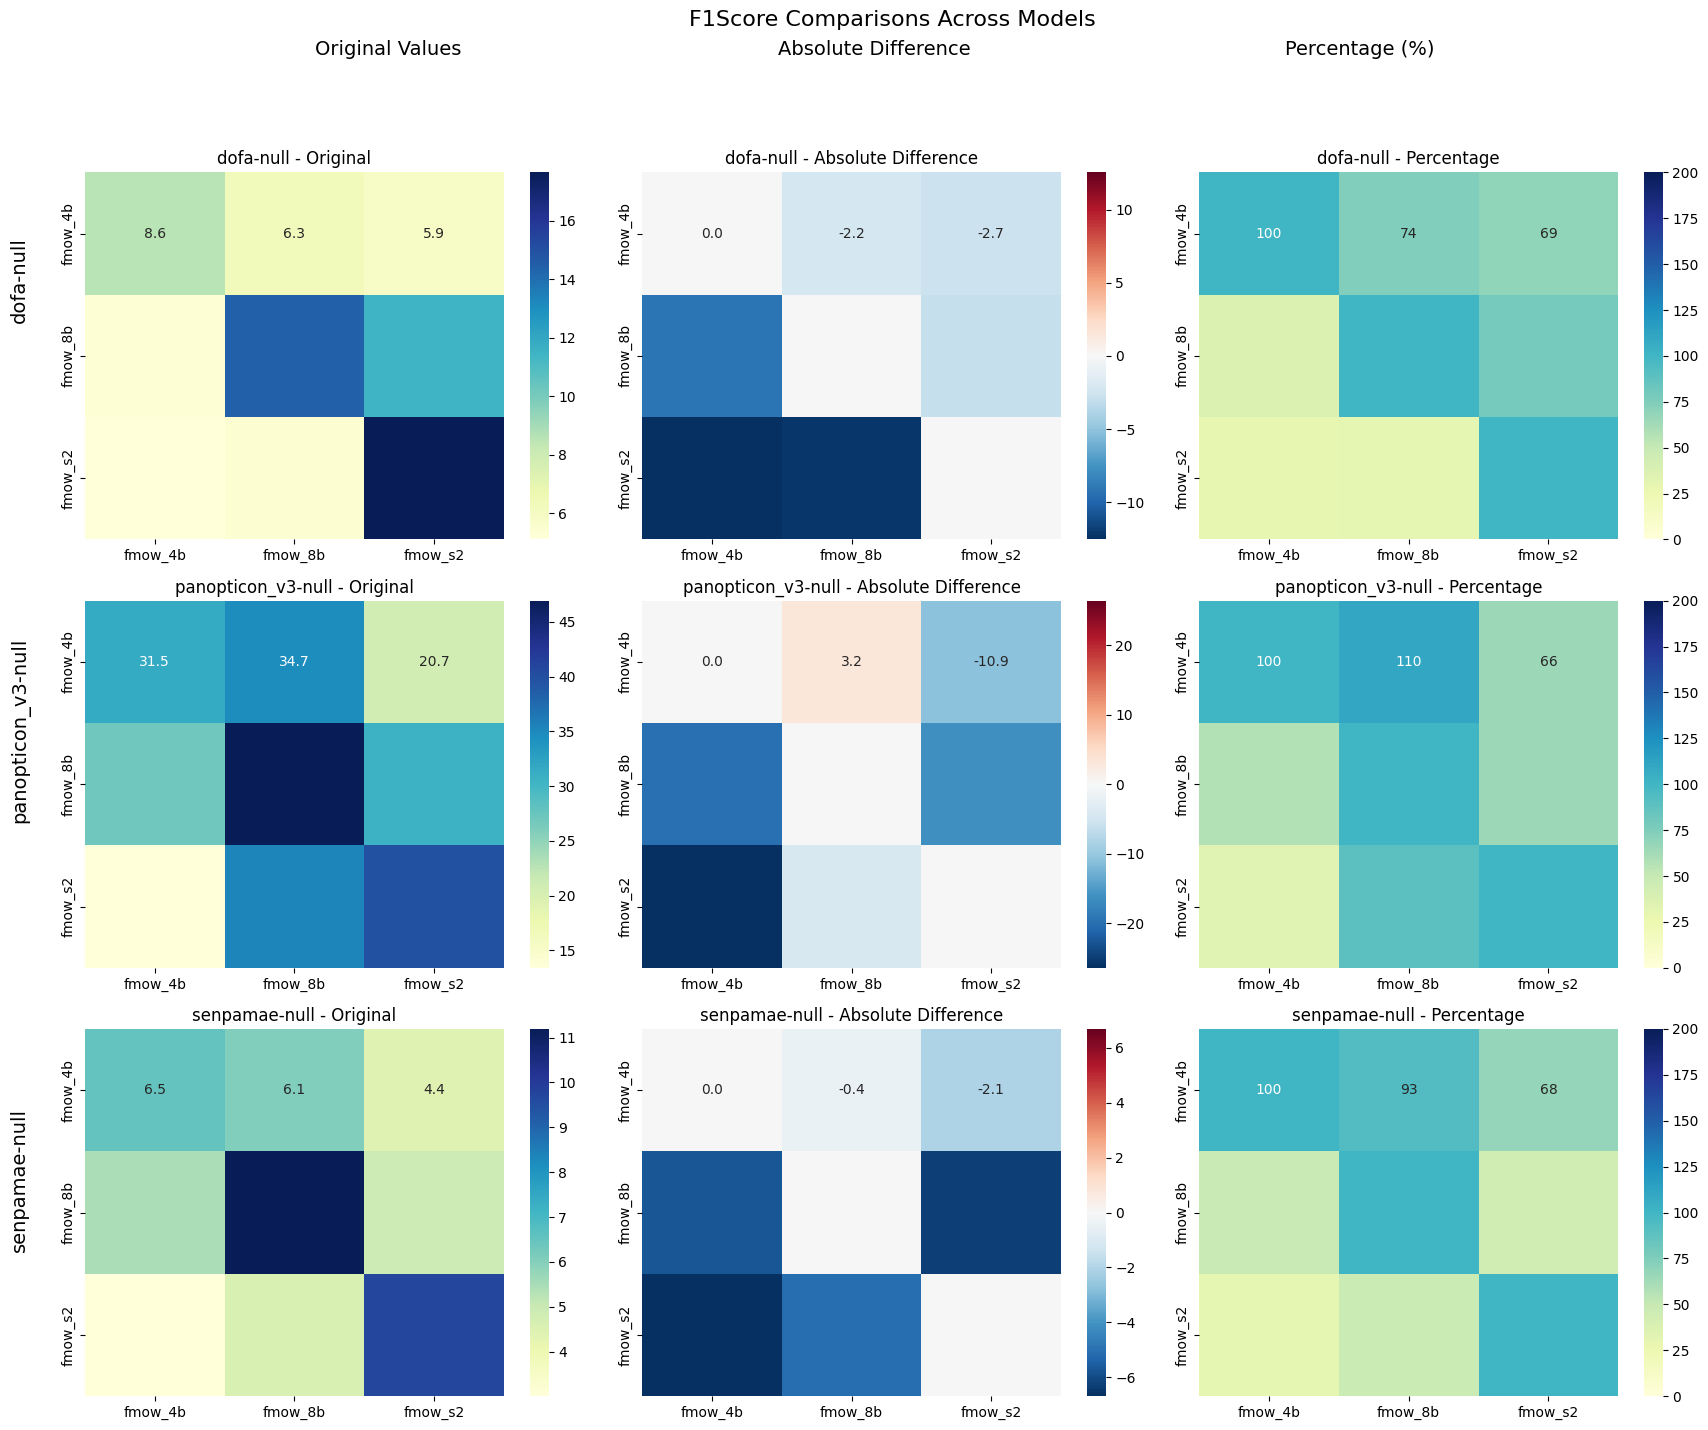

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Accuracy Comparisons Across Models', fontsize=16)

# Define the models and their positions
models_order = ['dofa-null', 'panopticon_v3-null', 'senpamae-null']

# Add column titles
column_titles = ['Original Values', 'Absolute Difference', 'Percentage (%)']
for i, title in enumerate(column_titles):
    fig.text(0.22 + i*0.27, 0.95, title, ha='center', fontsize=14)

# First metric only
metric = metrics[0]

# Plot each model
for i, model in enumerate(models_order):
    # Original values - explicitly convert to float
    original_data = model_dfs[model][metric].copy().astype(float)
    sns.heatmap(original_data, annot=True, fmt='.1f', 
                cmap='YlGnBu', ax=axes[i, 0], 
                mask=np.isnan(original_data))
    axes[i, 0].set_title(f"{model} - Original")
    
    # Absolute difference
    abs_diff_data = results_abs_diff[model][metric].copy().astype(float)
    # Find max absolute value for symmetric colormap
    max_abs = np.nanmax(np.abs(abs_diff_data.values))
    sns.heatmap(abs_diff_data, annot=True, fmt='.1f', 
                cmap='RdBu_r', center=0, ax=axes[i, 1],
                vmin=-max_abs, vmax=max_abs,
                mask=np.isnan(abs_diff_data))
    axes[i, 1].set_title(f"{model} - Absolute Difference")
    
    # Percentage
    perc_data = results_perc_diff[model][metric].copy().astype(float)
    sns.heatmap(perc_data, annot=True, fmt='.0f', 
                cmap='YlGnBu', vmin=0, vmax=max(200, np.nanmax(perc_data.values)),
                ax=axes[i, 2], mask=np.isnan(perc_data))
    axes[i, 2].set_title(f"{model} - Percentage")
    
    # Add row label
    fig.text(0.01, 0.8 - i*0.3, model, va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.92])
plt.show()

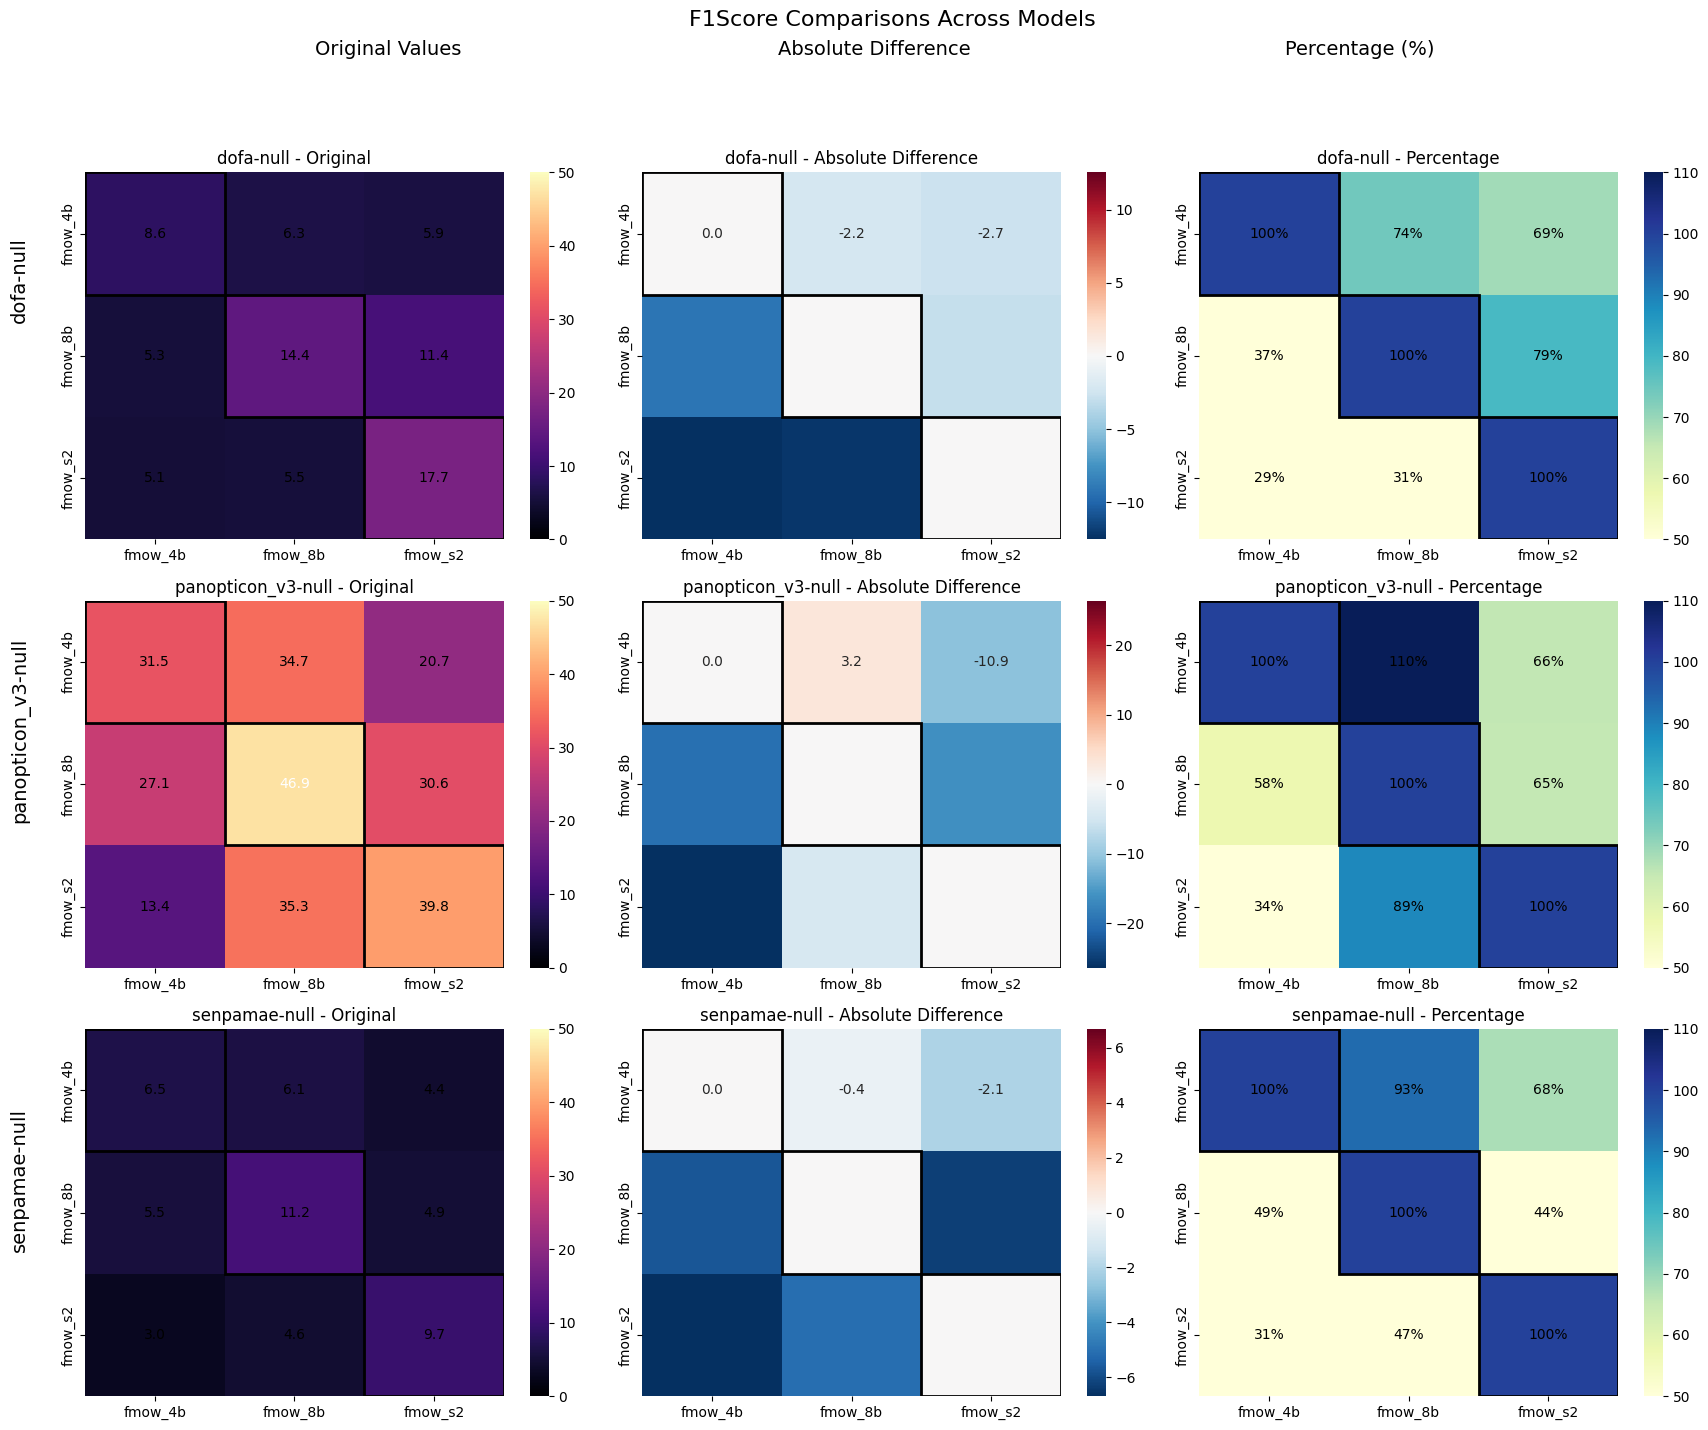

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('F1Score Comparisons Across Models', fontsize=16)

# Define the models and their positions
models_order = ['dofa-null', 'panopticon_v3-null', 'senpamae-null']

# Add column titles
column_titles = ['Original Values', 'Absolute Difference', 'Percentage (%)']
for i, title in enumerate(column_titles):
    fig.text(0.22 + i*0.27, 0.95, title, ha='center', fontsize=14)

# First metric only
metric = metrics[0]

# Plot each model
for i, model in enumerate(models_order):
    # Original values
    original_data = model_dfs[model][metric].copy().astype(float)
    
    # Create annotation array - convert to strings with 1 decimal place
    annot_orig = original_data.round(1).astype(str)
    # Replace NaN with empty string
    annot_orig = annot_orig.fillna('')
    
    sns.heatmap(original_data, annot=False, fmt='', 
                cmap='magma', ax=axes[i, 0], 
                mask=np.isnan(original_data),
                vmin=0, vmax=50)
    axes[i, 0].set_title(f"{model} - Original")

     # Manually add text annotations for original values
    for row_idx in range(len(original_data.index)):
        for col_idx in range(len(original_data.columns)):
            value = original_data.iloc[row_idx, col_idx]
            if not np.isnan(value):
                # Format with 1 decimal place
                text = f"{value:.1f}"
                # Position text in center of cell
                axes[i, 0].text(col_idx + 0.5, row_idx + 0.5, text,
                               ha='center', va='center',
                               color='black' if value < 40 else 'white')  # Adjust text color for readability
    
    
    
    # Absolute difference
    abs_diff_data = results_abs_diff[model][metric].copy().astype(float)
    
    # Create annotation array for absolute difference
    annot_abs = abs_diff_data.round(1).astype(str)
    annot_abs = annot_abs.fillna('')
    
    # Find max absolute value for symmetric colormap
    max_abs = np.nanmax(np.abs(abs_diff_data.values))
    sns.heatmap(abs_diff_data, annot=annot_abs, fmt='', 
                cmap='RdBu_r', center=0, ax=axes[i, 1],
                vmin=-max_abs, vmax=max_abs,
                mask=np.isnan(abs_diff_data))
    axes[i, 1].set_title(f"{model} - Absolute Difference")
    
    # Percentage
    perc_data = results_perc_diff[model][metric].copy().astype(float)
    
    # Create heatmap without annotations first
    sns.heatmap(perc_data, annot=False, 
                cmap='YlGnBu', vmin=50, vmax=110, # max(200, np.nanmax(perc_data.values)),
                ax=axes[i, 2], mask=np.isnan(perc_data))
    axes[i, 2].set_title(f"{model} - Percentage")
    
    # Manually add text annotations for percentage
    for row_idx in range(len(perc_data.index)):
        for col_idx in range(len(perc_data.columns)):
            value = perc_data.iloc[row_idx, col_idx]
            if not np.isnan(value):
                # Format as integer percentage
                text = f"{int(round(value, 0))}%"
                # Position text in center of cell
                axes[i, 2].text(col_idx + 0.5, row_idx + 0.5, text,
                               ha='center', va='center',
                               color='black' if value < 150 else 'white')  # Adjust text color for readability
    
    # Add row label
    fig.text(0.01, 0.8 - i*0.3, model, va='center', rotation='vertical', fontsize=14)

# Highlight the diagonals with black borders
for i, model in enumerate(models_order):
    for j in range(3):  # For each column (original, abs diff, percentage)
        ax = axes[i, j]
        for k in range(len(datasets)):
            ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=False, edgecolor='black', lw=2))

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.92])
plt.show()

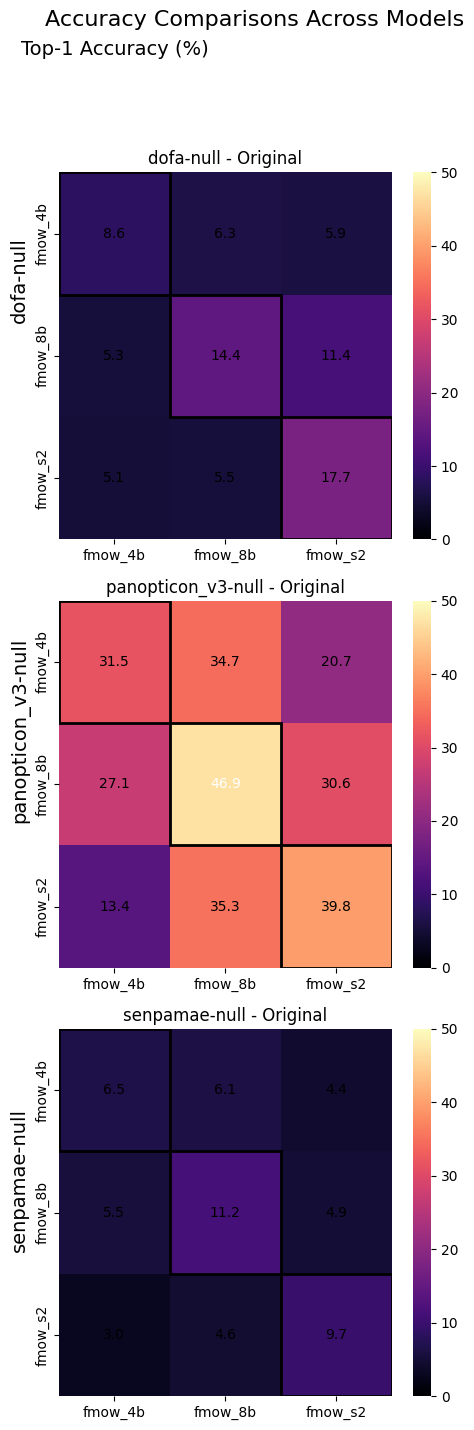

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(3, 1, figsize=(5, 15))
fig.suptitle('Accuracy Comparisons Across Models', fontsize=16)

# Define the models and their positions
models_order = ['dofa-null', 'panopticon_v3-null', 'senpamae-null']

# Add column titles
column_titles = ['Top-1 Accuracy (%)'] 
for i, title in enumerate(column_titles):
    fig.text(0.22 + i*0.27, 0.95, title, ha='center', fontsize=14)

# First metric only
metric = metrics[0]

# Plot each model
for i, model in enumerate(models_order):
    # Original values
    original_data = model_dfs[model][metric].copy().astype(float)
    
    # Create annotation array - convert to strings with 1 decimal place
    annot_orig = original_data.round(1).astype(str)
    # Replace NaN with empty string
    annot_orig = annot_orig.fillna('')
    
    sns.heatmap(original_data, annot=False, fmt='', 
                cmap='magma', ax=axes[i], 
                mask=np.isnan(original_data),
                vmin=0, vmax=50)
    axes[i].set_title(f"{model} - Original")

     # Manually add text annotations for original values
    for row_idx in range(len(original_data.index)):
        for col_idx in range(len(original_data.columns)):
            value = original_data.iloc[row_idx, col_idx]
            if not np.isnan(value):
                # Format with 1 decimal place
                text = f"{value:.1f}"
                # Position text in center of cell
                axes[i].text(col_idx + 0.5, row_idx + 0.5, text,
                               ha='center', va='center',
                               color='black' if value < 40 else 'white')  # Adjust text color for readability
    

    # Add row label
    fig.text(0.01, 0.8 - i*0.3, model, va='center', rotation='vertical', fontsize=14)

# Highlight the diagonals with black borders
for i, model in enumerate(models_order):
    ax = axes[i]
    for k in range(len(datasets)):
        ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=False, edgecolor='black', lw=2))

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.92])
plt.show()

/data/tmp/ipykernel_1207196/3350737281.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.03, 0.9, 0.92])  # Adjusted to make room for colorbar


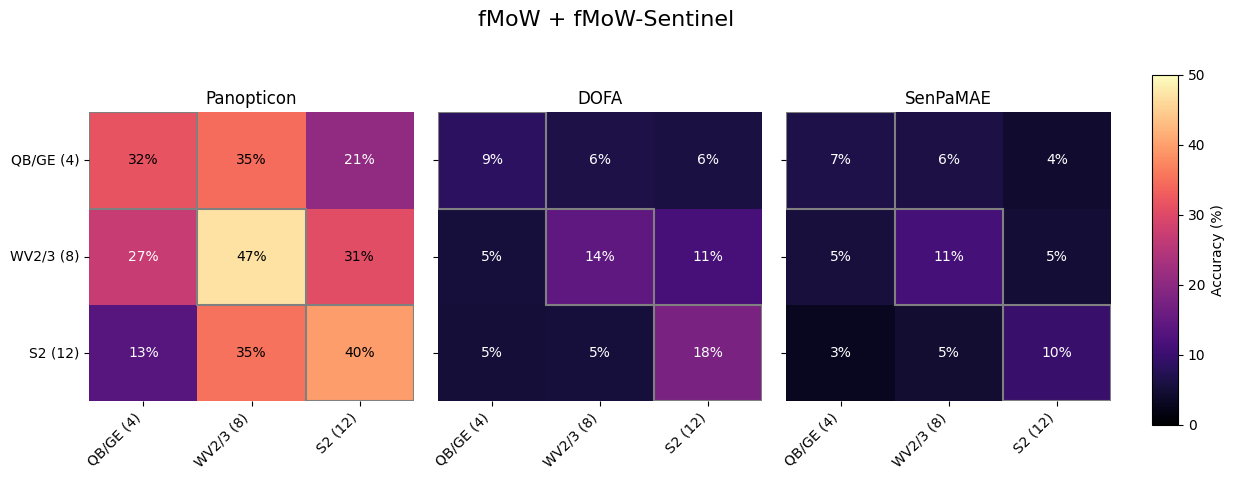

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure - changed to 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('fMoW + fMoW-Sentinel', fontsize=16)

# Define the models and their positions
models_order = ['panopticon_v3-null', 'dofa-null', 'senpamae-null']


model_display_names = {
    'dofa-null': 'DOFA',
    'panopticon_v3-null': 'Panopticon',
    'senpamae-null': 'SenPaMAE'
}

# Define dataset friendly names mapping
dataset_display_names = {
    datasets[0]: 'QB/GE (4)',
    datasets[1]: 'WV2/3 (8)',
    datasets[2]: 'S2 (12)'
}
# First metric only
metric = metrics[0]

# Create a norm object for consistent color scaling across all plots
norm = plt.Normalize(vmin=0, vmax=50)

# Plot each model
for i, model in enumerate(models_order):
    # Original values
    original_data = model_dfs[model][metric].copy().astype(float)
    
    # Create annotation array - convert to strings with 1 decimal place
    annot_orig = original_data.round(1).astype(str)
    # Replace NaN with empty string
    annot_orig = annot_orig.fillna('')
    
    # Use the same norm for all heatmaps and don't show colorbar for individual plots
    sns.heatmap(original_data, annot=False, fmt='', 
                cmap='magma', ax=axes[i], 
                mask=np.isnan(original_data),
                norm=norm, cbar=False)
    # Use friendly model name for title
    axes[i].set_title(model_display_names[model])
    
    # Update axis labels with friendly dataset names
    if i == 0:  # Only need to do this for the first subplot's y-axis
        axes[i].set_yticklabels([dataset_display_names.get(dataset, dataset) for dataset in original_data.index], rotation=0)
    else:
        axes[i].set_yticklabels([])  # Hide y-axis labels for other subplots
    
    # Update x-axis labels with friendly dataset names
    axes[i].set_xticklabels([dataset_display_names.get(dataset, dataset) for dataset in original_data.columns], rotation=45, ha='right')


    # Manually add text annotations for original values
    for row_idx in range(len(original_data.index)):
        for col_idx in range(len(original_data.columns)):
            value = original_data.iloc[row_idx, col_idx]
            if not np.isnan(value):
                # Format with 1 decimal place
                text = f"{value:.0f}%"
                # Position text in center of cell
                axes[i].text(col_idx + 0.5, row_idx + 0.5, text,
                               ha='center', va='center',
                               color='black' if value > 30 else 'white')  # Adjust text color for readability

    # Highlight the diagonals with black borders
    for k in range(len(datasets)):
        axes[i].add_patch(plt.Rectangle((k, k), 1, 1, fill=False, edgecolor='gray', lw=1.5))

# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Accuracy (%)')

plt.tight_layout(rect=[0.03, 0.03, 0.9, 0.92])  # Adjusted to make room for colorbar
plt.show()

/data/tmp/ipykernel_1207196/905900553.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)
/data/tmp/ipykernel_1207196/905900553.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)
/data/tmp/ipykernel_1207196/905900553.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)
/data/tmp/ipykernel_1207196/905900553.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)
/data/tmp/ipykernel_

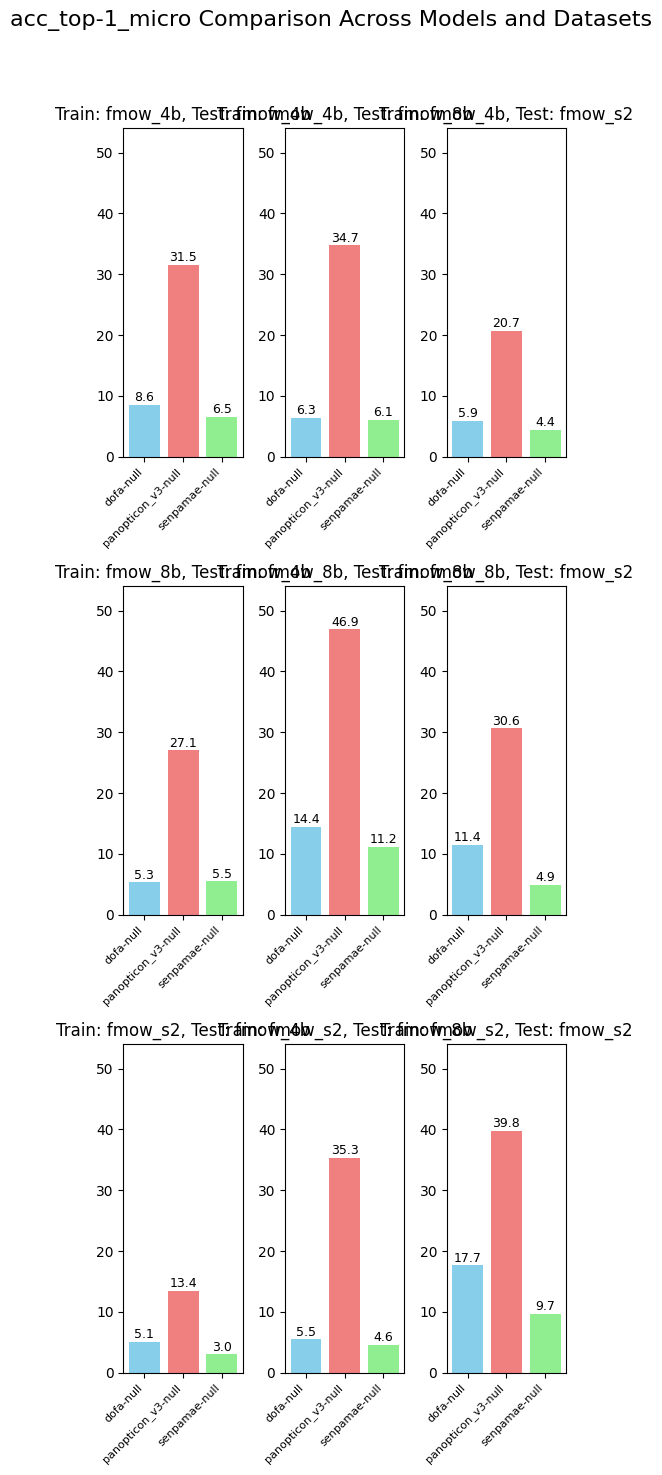

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# First metric only
# metric = 'F1Score'

maxi = 45

# Set up the figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle(f'{metric} Comparison Across Models and Datasets', fontsize=16)

# Define colors for each model
colors = {'dofa-null': 'skyblue', 'panopticon_v3-null': 'lightcoral', 'senpamae-null': 'lightgreen'}

# For each train-test dataset combination
for i, train_ds in enumerate(datasets):
    for j, test_ds in enumerate(datasets):
        ax = axes[i, j]
        
        # Extract values for this dataset combination
        values = [model_dfs[model][metric].loc[train_ds, test_ds] for model in models_order]
        
        # Create bar chart
        bars = ax.bar(models_order, values, color=[colors[model] for model in models_order])
        
        # Add value labels on top of bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.1f}', ha='center', va='bottom', fontsize=9)
        
        # Set title and labels
        ax.set_title(f'Train: {train_ds}, Test: {test_ds}')
        ax.set_ylim(0, maxi * 1.2)  # Add some space for labels
        
        # Rotate x-axis labels for readability
        ax.set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

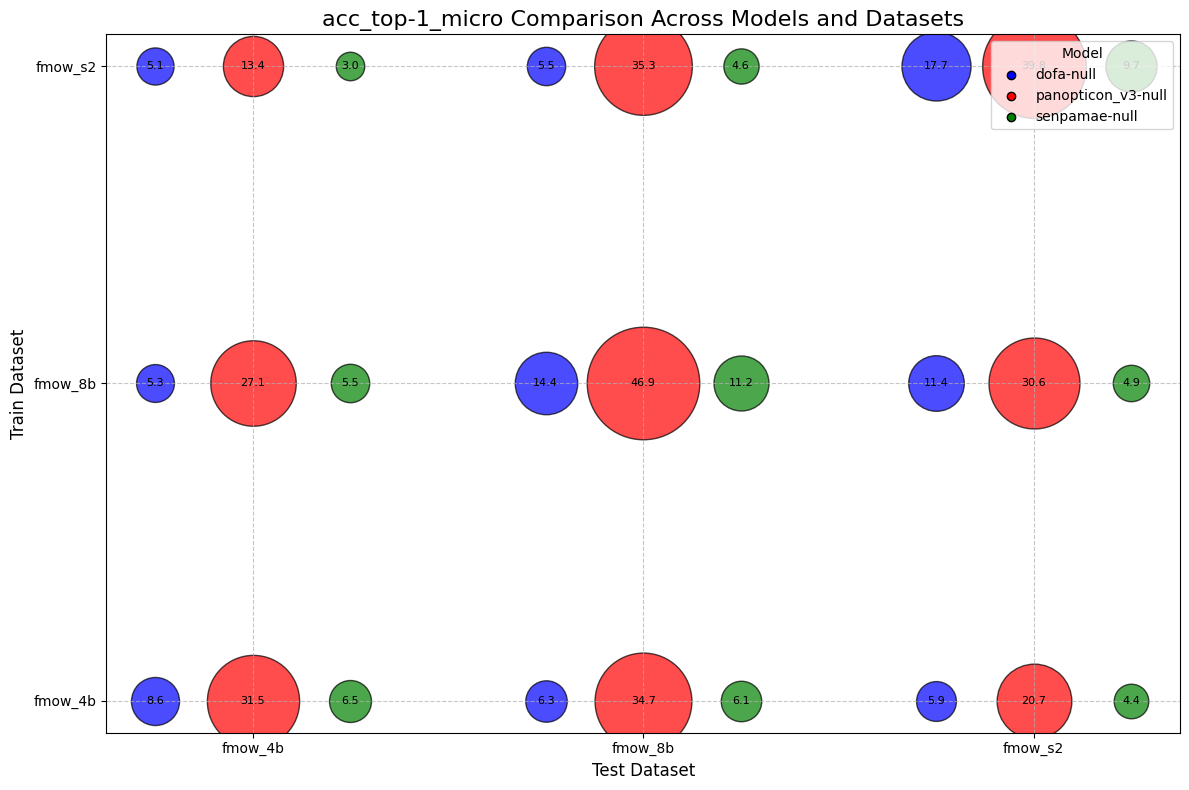

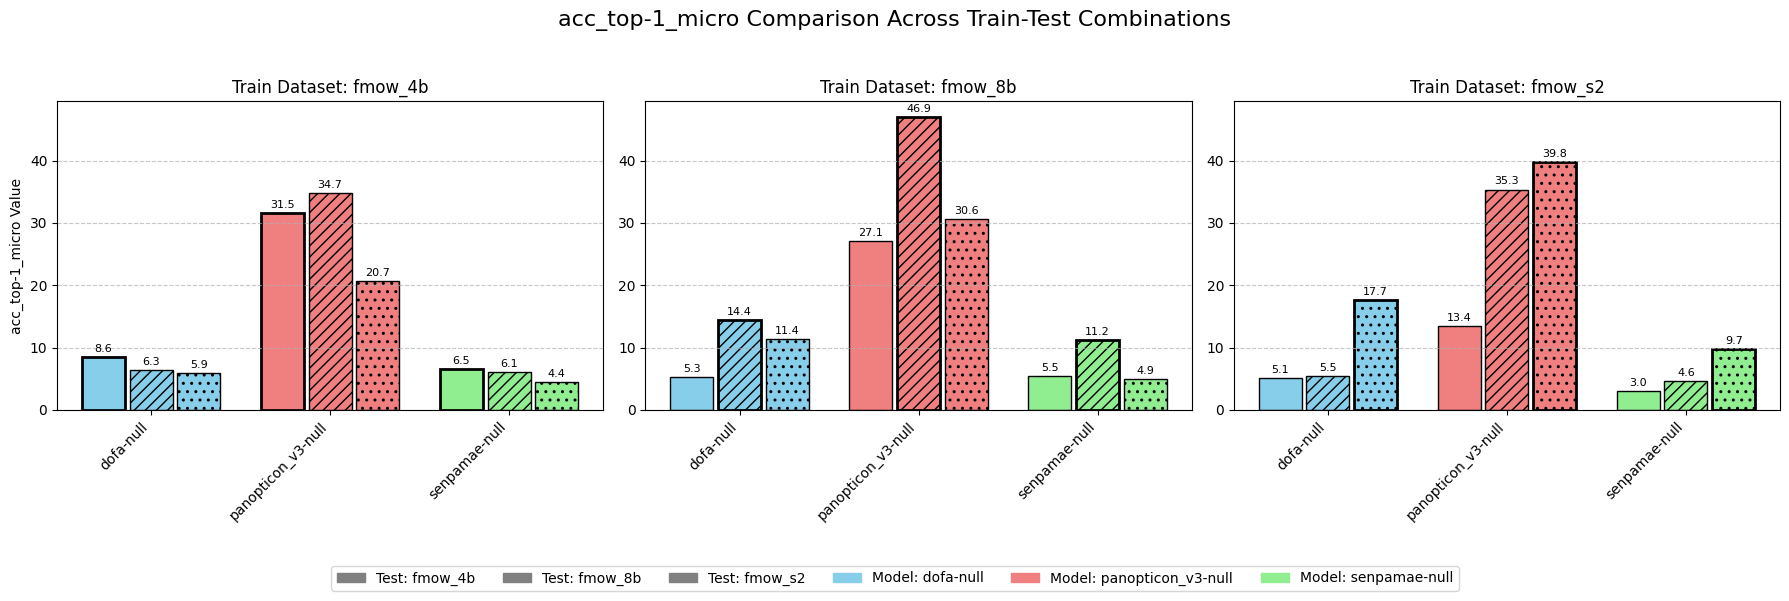

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# First metric only
# metric = 'F1Score'

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'{metric} Comparison Across Train-Test Combinations', fontsize=16)

# Define colors for each model
model_colors = {
    'dofa-null': 'skyblue', 
    'panopticon_v3-null': 'lightcoral', 
    'senpamae-null': 'lightgreen'
}

# Define hatching patterns for test datasets (consistent across all plots)
test_hatches = {
    datasets[0]: '',      # No hatching for first dataset
    datasets[1]: '///',   # Diagonal hatching for second dataset
    datasets[2]: '..'    # Cross hatching for third dataset
}

# For each train dataset (column)
for i, train_ds in enumerate(datasets):
    ax = axes[i]
    
    # Calculate number of groups and bars per group
    n_models = len(models_order)
    n_test = len(datasets)
    
    # Set up positions for grouped bars
    bar_width = 0.8 / n_test
    group_positions = np.arange(n_models)
    
    # For each test dataset
    for j, test_ds in enumerate(datasets):
        # Extract absolute values for this train-test combination
        values = [model_dfs[model][metric].loc[train_ds, test_ds] for model in models_order]
        
        # Determine bar style
        colors = [model_colors[model] for model in models_order]
        hatch = test_hatches[test_ds]
        label = f'Test: {test_ds}'
        
        # Highlight diagonal with thicker edge
        edge_color = 'black'
        edge_width = 2 if test_ds == train_ds else 1
        
        # Calculate bar positions
        bar_positions = group_positions + j * bar_width
        
        # Create bars
        bars = ax.bar(
            bar_positions, 
            values, 
            bar_width * 0.9, 
            label=label, 
            color=colors,
            edgecolor=edge_color,
            linewidth=edge_width,
            hatch=hatch
        )
        
        # Add value labels on top of bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                height + 0.5,
                f'{value:.1f}', 
                ha='center', 
                va='bottom', 
                fontsize=8
            )
    
    # Set title and labels
    ax.set_title(f'Train Dataset: {train_ds}')
    ax.set_ylabel(f'{metric} Value' if i == 0 else '')
    ax.set_xticks(group_positions + (n_test-1) * bar_width / 2)
    ax.set_xticklabels(models_order, rotation=45, ha='right')
    
    # Add grid lines for readability
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis to start at 0
    ax.set_ylim(0, 45 * 1.1)

# Create a single legend for all plots
handles, labels = [], []
for test_ds in datasets:
    # Create a dummy patch for the legend
    handle = plt.Rectangle(
        (0, 0), 1, 1, 
        fill=True, 
        color='gray',
        hatch=test_hatches[test_ds]
    )
    handles.append(handle)
    labels.append(f'Test: {test_ds}')

# Add model colors to the legend
for model in models_order:
    handle = plt.Rectangle(
        (0, 0), 1, 1, 
        fill=True, 
        color=model_colors[model]
    )
    handles.append(handle)
    labels.append(f'Model: {model}')

# Place the legend below the plots
fig.legend(handles, labels, loc='lower center', ncol=len(datasets) + len(models_order), bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Adjust bottom margin for legend
plt.show()